In [101]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import astropy
from astropy.io import fits
from astropy.visualization import ImageNormalize, MinMaxInterval, PercentileInterval, AsinhStretch, AsymmetricPercentileInterval, make_lupton_rgb
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.convolution import Gaussian2DKernel, convolve

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, detect_threshold

import skimage as ski
from skimage.segmentation import inverse_gaussian_gradient, morphological_geodesic_active_contour
from skimage.measure import regionprops

from scipy import ndimage

# Extracción de datos RAW

In [9]:
gname = '1-210759_grz.fits'
fits_path = Path.cwd()/Path(f'FITS/{gname}')#FITS\1-115357_grz.fits
#open fits file
hdulist= fits.open(fits_path)
hdulist.info()
headers = fits.getheader(fits_path)
image_data= fits.getdata(fits_path)
hdulist.close()
    

Filename: c:\Users\jfmag\OneDrive\Documentos\Maestria\Proyecto integrador\FITS\1-210759_grz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   (800, 800, 3)   float32   


In [10]:
headers

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                  800 / length of data axis 1                          
NAXIS2  =                  800 / length of data axis 2                          
NAXIS3  =                    3 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
SURVEY  = 'LegacySurvey'                                                        
VERSION = 'DR10    '                                                            
IMAGETYP= 'IMAGE   '           / None                                           
BANDS   = 'grz     '        

In [11]:
image_data[2]

array([[-0.03071264, -0.01147539, -0.01035713, ..., -0.00454711,
        -0.00652034, -0.00323976],
       [-0.01060346,  0.00708081, -0.01802067, ...,  0.00338461,
         0.00325567,  0.00039947],
       [ 0.00557403, -0.00344873, -0.00474934, ..., -0.00526743,
        -0.00489654,  0.02099175],
       ...,
       [-0.00597159,  0.00634112,  0.00536845, ..., -0.02498442,
        -0.01620089, -0.00128926],
       [-0.01060825, -0.00014616,  0.00833523, ...,  0.00162098,
         0.00729776,  0.01005933],
       [ 0.00334687, -0.00815693, -0.01733048, ...,  0.01983782,
        -0.00402487, -0.0279318 ]], shape=(800, 800), dtype='>f4')

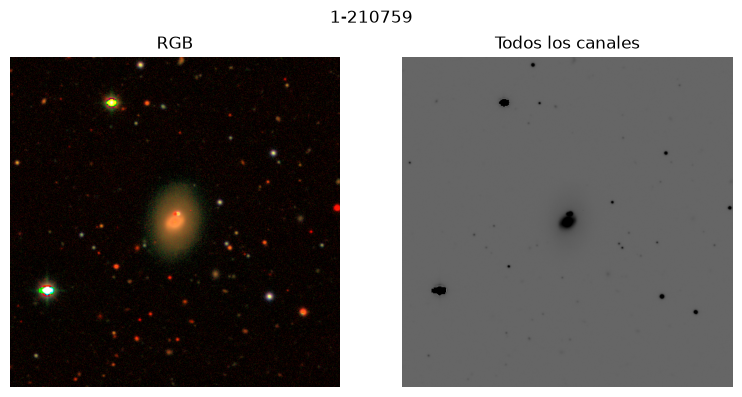

In [12]:
gal_rgb = make_lupton_rgb(image_r=image_data[2], image_g=image_data[1], image_b=image_data[0], stretch=0.1)
#Banda Rojo visible - canal R + Banda UV - canal G + Banda Z - canal B
gal_chnls = image_data[2] + image_data[1] + image_data[0]
gal_name = gname.split(sep="_")[0]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
fig.suptitle(f'{gal_name}')
#rgb
luz_rgb = np.median(gal_rgb) + np.std(gal_rgb)*2
ax[0].imshow(gal_rgb, vmin =np.min(gal_rgb) , vmax=luz_rgb,  origin='lower')
ax[0].set_title('RGB')
ax[0].axis('off')
# todos los canales
luz_ch = np.median(gal_chnls) + np.std(gal_chnls)*2
ax[1].imshow(gal_chnls, vmin=np.min(gal_chnls), vmax=luz_ch ,origin='lower', cmap='Greys')
ax[1].set_title('Todos los canales')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
print(f'Estadística RGB:\n avg:{np.mean(gal_rgb)}\n med:{np.median(gal_rgb)}\n std:{np.std(gal_rgb)}\n min:{np.min(gal_rgb)}\n max:{np.max(gal_rgb)}')
print(f'Estadística Channels:\n avg:{np.mean(gal_chnls)}\n med:{np.median(gal_chnls)}\n std:{np.std(gal_chnls)}\n min:{np.min(gal_chnls)}\n max:{np.max(gal_chnls)}')

Estadística RGB:
 avg:8.586425520833334
 med:0.0
 std:21.15655393440408
 min:0
 max:255
Estadística Channels:
 avg:0.04523366689682007
 med:0.0020576626993715763
 std:0.8816704154014587
 min:-3.6280436515808105
 max:33.22059631347656


# Aislamiento de la galaxia - efecto "cartulina negra"

## Cálculo de estadísticas con sigma_clipped_stats

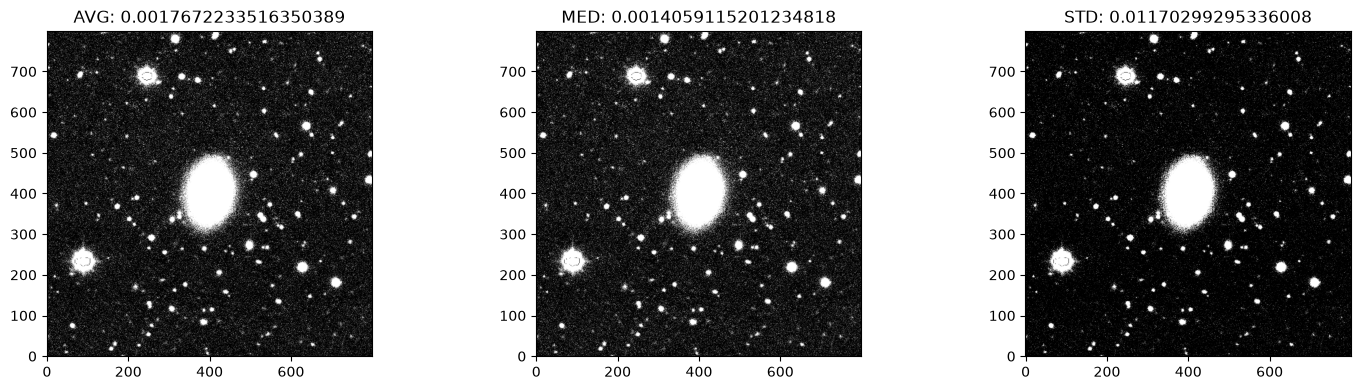

In [14]:
# Métricas sigma-clipped
stats_clp= sigma_clipped_stats(data=gal_chnls, sigma=3.5, maxiters=10)

fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(15,4))
axs[0].imshow(gal_chnls, vmin=stats_clp[0], vmax=np.mean(gal_chnls), cmap="grey", origin='lower')
axs[0].set_title(f'AVG: {stats_clp[0]}')
axs[1].imshow(gal_chnls, vmin=stats_clp[1], vmax=np.mean(gal_chnls), cmap="grey", origin='lower')
axs[1].set_title(f'MED: {stats_clp[1]}')
axs[2].imshow(gal_chnls, vmin=stats_clp[2], vmax=np.mean(gal_chnls), cmap="grey", origin='lower')
axs[2].set_title(f'STD: {stats_clp[2]}')

plt.tight_layout()
plt.show()


## Estimación de métricas del background

In [15]:
def metricas_fondo (arreglo):
    '''
    El objetivo de la función es poder detectar el valor de fondo para cada canal de las diferentes imágenes.
    Pipeline:
        1. Obtener el box_size que es dato más importante para calcular el los "bloques" en los que se va a analizar al imagen.
            1. Cálculo d ela mediana con sigma_clipped_stats
            2. Uso regionprops, sirve para hacer varios segmentos de la imagen
            3. Obtengo el valor de axis_major_length, esto lo obtengo del valor que tenga la area más grande.
            4. Calculo el tamaño del box size y filter; dejo un valor fijo de alpha 5, lo anterior basado en que si aplico un alpha de 4 ó 6 tendría box muy grande o muy pequeño, perdiendo propiedades de la galaxia
            NOTA: EL BOX_SIZE y el FILTER requieren ser números impares
        2. Cálculo del valor del fondo (cielo astronómico).
            1. Implemento photutils.background.Background2D para obtener el valor del cielo astronómico.
    Return Empaqueto todos los resultados de los arreglos son ruido, la mediana de sigma_clipped_stats, y los arreglos de los backgrounds
    '''
    sc = SigmaClip(sigma=3.0)
    back_median = MedianBackground(sigma_clip=sc)

    #Métricas del cielo astronómico por canal
    _, sc_med, sc_std = sigma_clipped_stats(data=arreglo,sigma=3.5, maxiters=10)
    #obtengo el regionprops
    reg_props = regionprops(np.astype(arreglo,int))
    #obtención del tamaño del eje mas grande de una elipse que engloba la galaxia
    max_axis = [i.axis_major_length for i in reg_props if i.area == max([i.area for i in reg_props])][0] #resto 1 para tener el índice correcto, los labels están recorridos
    #tamaño box_size y filtros
    bs = int(np.round(max_axis / 5, 0))
    filters = int(np.round(2 * (bs / 20) + 1, 0))
    if bs %2 ==0: bs+=1
    if filters%2==0: filters +=1

    #cálculo del ruido por canal y recalculo los valores de los arreglos
    bkg = Background2D(arreglo, box_size=(bs, bs), filter_size=(filters, filters), 
            sigma_clip=sc, bkg_estimator=back_median, filter_threshold=sc_std)
    arr_cielo_canal = arreglo - bkg.background

    #guardo el valor por cada canal
    arr_cielo = arr_cielo_canal
    sc = sc_med
    bkg = bkg
    
    dict_datos = {
        "fits": arr_cielo,
        "cielo_med": sc,
        "bkgs": bkg
    }
    return dict_datos



In [16]:
bkgs = metricas_fondo(gal_chnls)

## Normalización de la imagen

In [17]:
def norm_fits (arr_galaxia_channels):
    '''
    Descripción del pipeline:
        1. Cálculo de las métricas del cielo astronómico
        2. Cálculo de los valores alpha para los tipos de escalamiento (lupton, lupton estándar y estadístico)
        3. Instanciar los tipos de normalización de la imagen
        4. Normalización de la imagen
    RETURN arreglos y normalizaciones por canal

    NOTA: RECORDAR QUE SE SUMARON LSO 3 CANALES, POR LO TANTO AHORA ES SÓLO 1 ARREGLO
    '''
    # cálculo de valores alpha para hacer el AsinhStrech
    _, med_cielo, std_cielo = sigma_clipped_stats(arr_galaxia_channels, sigma=3, maxiters=10)
    denominador = np.max(arr_galaxia_channels)-np.min(arr_galaxia_channels)
    alpha_lupton= std_cielo/denominador
    alpha_lest = std_cielo*3
    alpha_est = (med_cielo-np.min(arr_galaxia_channels))/denominador

    #instancio los tipo de normalización
    minmax = MinMaxInterval()
    itqr = PercentileInterval(percentile=98)
    aprint = AsymmetricPercentileInterval(lower_percentile=1, upper_percentile=98)
    asin_lupton = AsinhStretch(a=alpha_lupton)
    asin_lest = AsinhStretch(a=alpha_lest)
    asin_est = AsinhStretch(a=alpha_est)

    #normalización con lupton
    minmax_lupton = ImageNormalize(data=arr_galaxia_channels,interval=minmax, stretch=asin_lupton)
    percent_lupton = ImageNormalize(data=arr_galaxia_channels,interval=itqr, stretch=asin_lupton)
    aprint_lupton = ImageNormalize(data=arr_galaxia_channels,interval=aprint, stretch=asin_lupton)
    #normalización con lupton estándar
    minmax_lest = ImageNormalize(data=arr_galaxia_channels,interval=minmax, stretch=asin_lest)
    percent_lest = ImageNormalize(data=arr_galaxia_channels,interval=itqr, stretch=asin_lest)
    aprint_lest = ImageNormalize(data=arr_galaxia_channels,interval=aprint, stretch=asin_lest)
    #normalización con estadítico
    minmax_est = ImageNormalize(data=arr_galaxia_channels,interval=minmax, stretch=asin_est)
    percent_est = ImageNormalize(data=arr_galaxia_channels,interval=itqr, stretch=asin_est)
    aprint_est = ImageNormalize(data=arr_galaxia_channels,interval=aprint, stretch=asin_est)

    minmax_lupton=minmax_lupton
    percent_lupton=percent_lupton
    aprint_lupton=aprint_lupton
    minmax_lest=minmax_lest
    percent_lest=percent_lest
    aprint_lest=aprint_lest
    minmax_est=minmax_est
    percent_est=percent_est
    aprint_est=aprint_est

    return {
            "MinMax Lupton":minmax_lupton, "Percentile Lupton":percent_lupton, "Asym Per Lupton":aprint_lupton,
            "MinMax Lupton Est":minmax_lest, "Percentile Lupton Est":percent_lest, "Asym Per Lup Est":aprint_lest,
            "MinMax Est":minmax_est, "Percentile Est":percent_est, "Asym Per Est":aprint_est
            }
            

In [18]:
norm_imgs = norm_fits(bkgs['fits'])

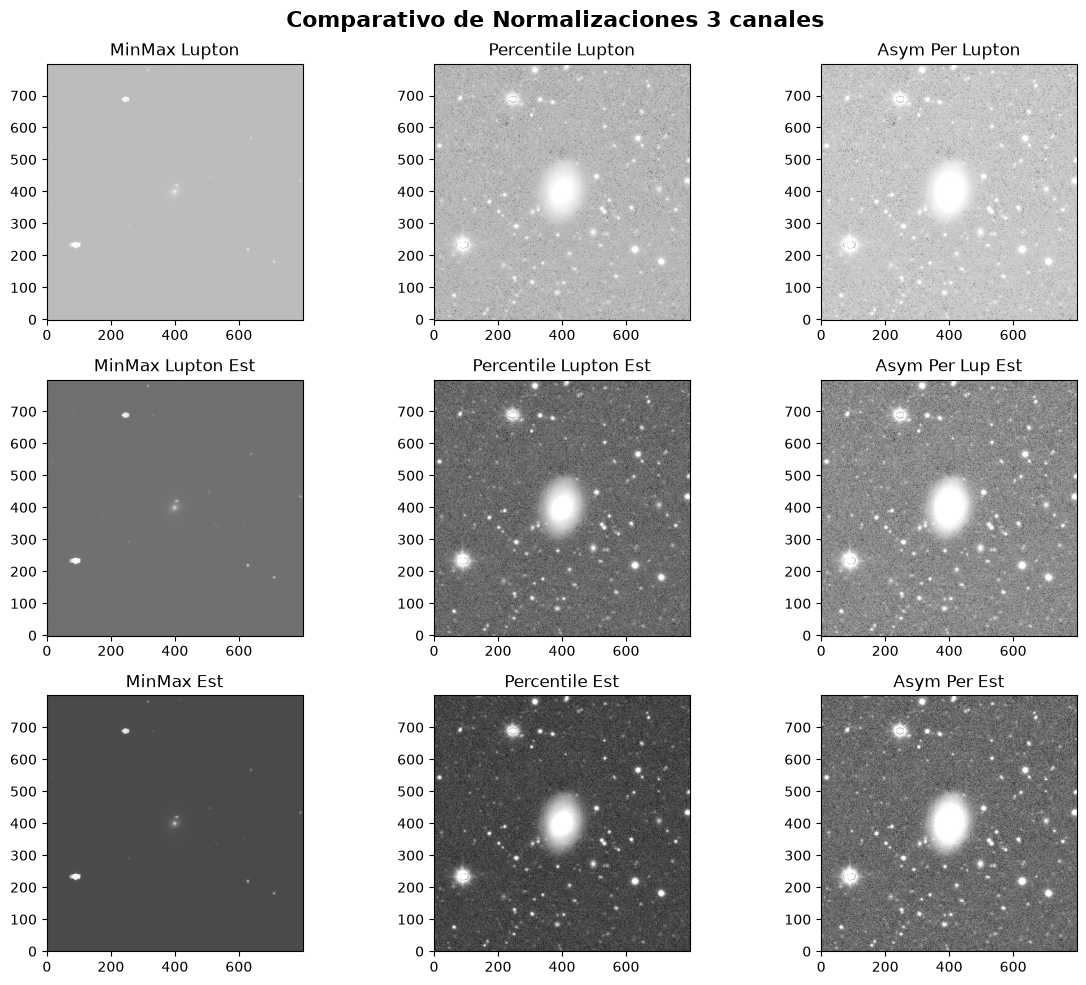

In [19]:
#gráficas banda Z normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
axs = axs.ravel()
fig.suptitle('Comparativo de Normalizaciones 3 canales' , fontsize=16, fontweight='bold')
for (k,v), ax in zip(norm_imgs.items(),axs):
    ax.imshow(bkgs['fits'], norm = v, origin='lower', cmap='grey')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

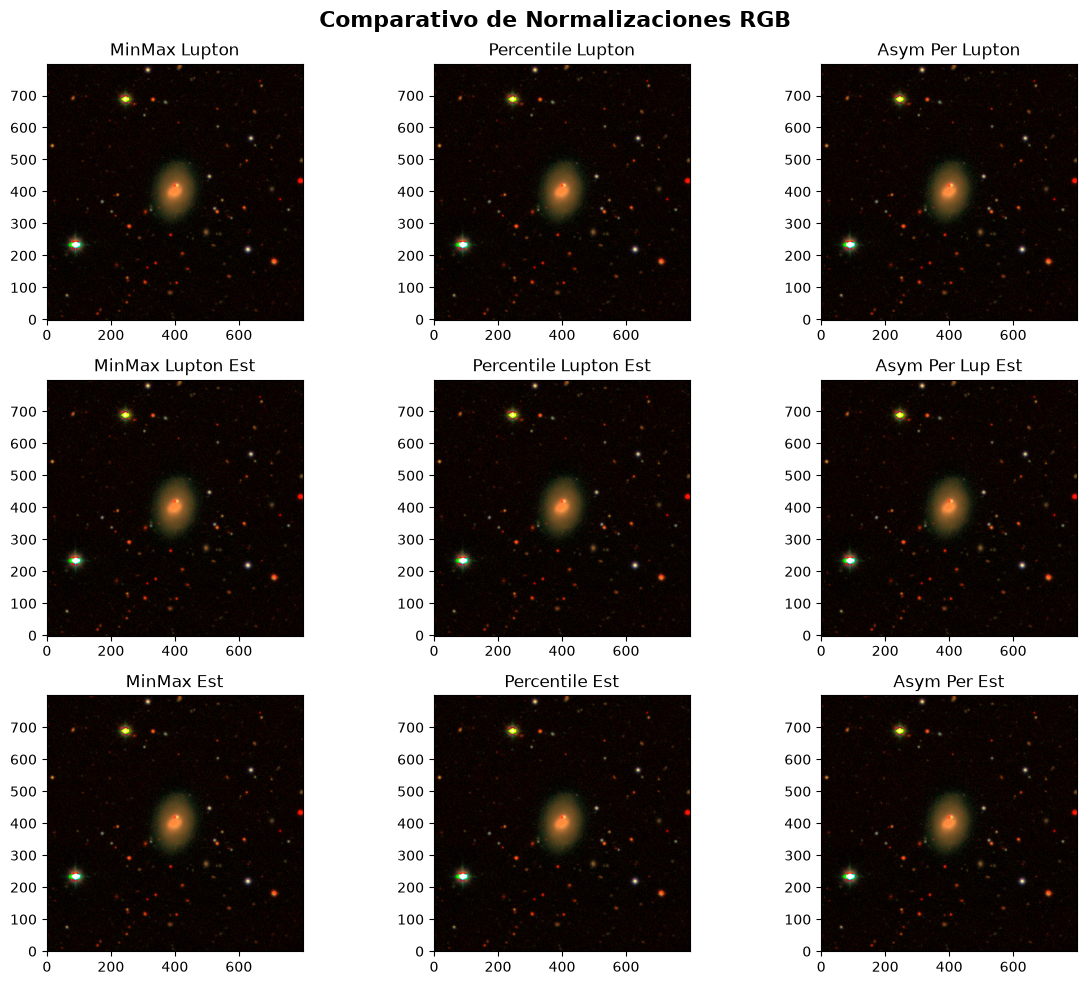

In [20]:
#gráficas RGB normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
fig.suptitle('Comparativo de Normalizaciones RGB', fontsize=16, fontweight='bold')
axs = axs.ravel()

for (k,v), ax in zip(norm_imgs.items(),axs):
    ax.imshow(gal_rgb, norm = v, origin='lower')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

## Implementación de máscara Gaussiana

In [21]:
def mascara_gaussiana(arreglo, stats):
    '''
    Descripción del pipeline:
    1. Obtener la segmentación gaussina para separar la galaxia
    2. Elaborar la máscara booleana, este caso sólo se hace el cálculo bajo un solo canal
    Return el boolean mask, y el seg_gaus
    '''
    ## PASO 1:
    #instancio los Kernels
    g2dK=Gaussian2DKernel(x_stddev=3, y_stddev=3)
    #convolusionamos la data
    convolve_Gauss = convolve(arreglo, g2dK)
    
    #detecta sources
    avg_u, med_u, std_u = sigma_clipped_stats(convolve_Gauss, sigma=3, maxiters=10)
    if stats==' avg':
        st= avg_u
    elif stats=='std':
        st=std_u
    else:
        st=med_u

    umbral = detect_threshold(convolve_Gauss,n_sigma=5, error=st)
    #segmento la imágen
    seg_gauss = detect_sources(data=convolve_Gauss, threshold=umbral, n_pixels=5, connectivity=4)
    
    ##PASO 2:
    # Quedarnos sólo con la imagen el centro
    # 1. Obetner los descriptores geométricos de cada segmentación de la imagen
    segments = regionprops(label_image=seg_gauss.data)
    #2. Extraer la propieadad coords para ubicar cada una de las coordenadas en un acomprehension list
    cl_coords = [(s.label, np.sqrt((s.centroid[0]-400)**2 +(s.centroid[1]-400)**2 )) for s in segments]
    #3. obtener el valor mínimo de de la comprehensión list, esto porque es el que tiene la menor distancia del centro del imagen
    id_galaxia=min(cl_coords, key= lambda dist:dist[1])
    bm_galaxia = seg_gauss.data == id_galaxia[0]

    return bm_galaxia, seg_gauss

In [22]:
#mascara_gaussiana(arreglo_rgb, nsigma, multiplo, stats, banda)
mascara = mascara_gaussiana(gal_chnls, stats = 'std')

Text(0.5, 1.0, 'Máscara booleana')

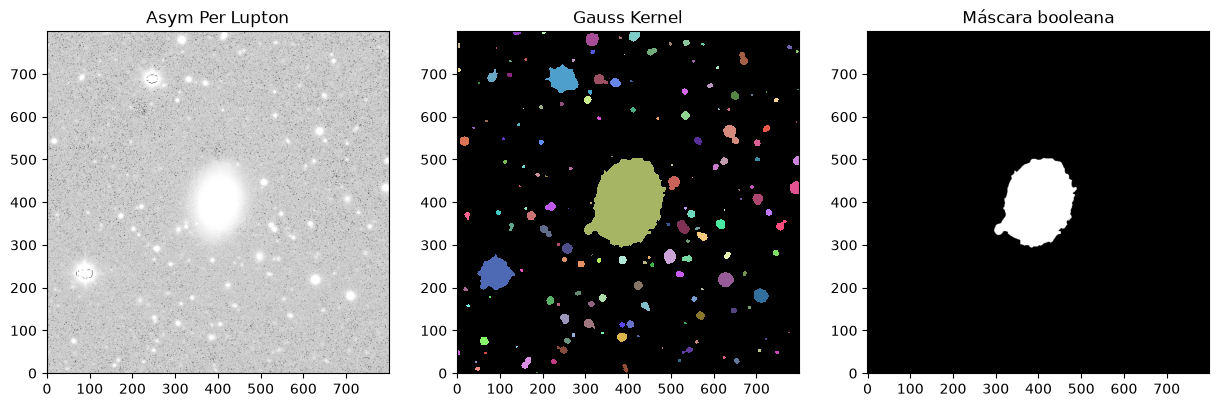

In [23]:
#grafico la segmentación de la galaxia
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(15,10))
axs[0].imshow(gal_chnls, origin='lower', cmap="grey", norm = norm_imgs['Asym Per Lupton'])
axs[0].set_title('Asym Per Lupton')
mascara[1].imshow(ax=axs[1])
axs[1].set_title('Gauss Kernel')
axs[2].imshow(mascara[0], cmap='grey', origin='lower')
axs[2].set_title('Máscara booleana')

## Limpieza de estrellas - "cartulina negra"

In [92]:
def limpieza_estrellas(arreglo, backgrounds, mask):
    '''
    Descripción del pipeline:
    1. Cáculo del STD con sigma_clipped_stats
    2. Convertir todos aquellos valores que no pertenecen a la galaxia al valor de STD
    RETURN por canal con el nuevo fondo sin tocar la galaxia

    NOTA: Esto se hace por canal
    '''
    #"bkgs": {"r": bkg_r, "g": bkg_g, "b": bkg_b},
    for idx, arr in enumerate(arreglo):
        _,_,std_bkg = sigma_clipped_stats(backgrounds.background_rms, sigma=3, maxiters=10) 
        glx_lim = np.copy(a=arr)
        glx_lim = np.where(~mask, std_bkg, glx_lim)

        if idx==0:
            glx_b= glx_lim
        elif idx==1:
            glx_g= glx_lim
        else:
            glx_r= glx_lim

    return np.stack([glx_b, glx_g, glx_r], axis=0)

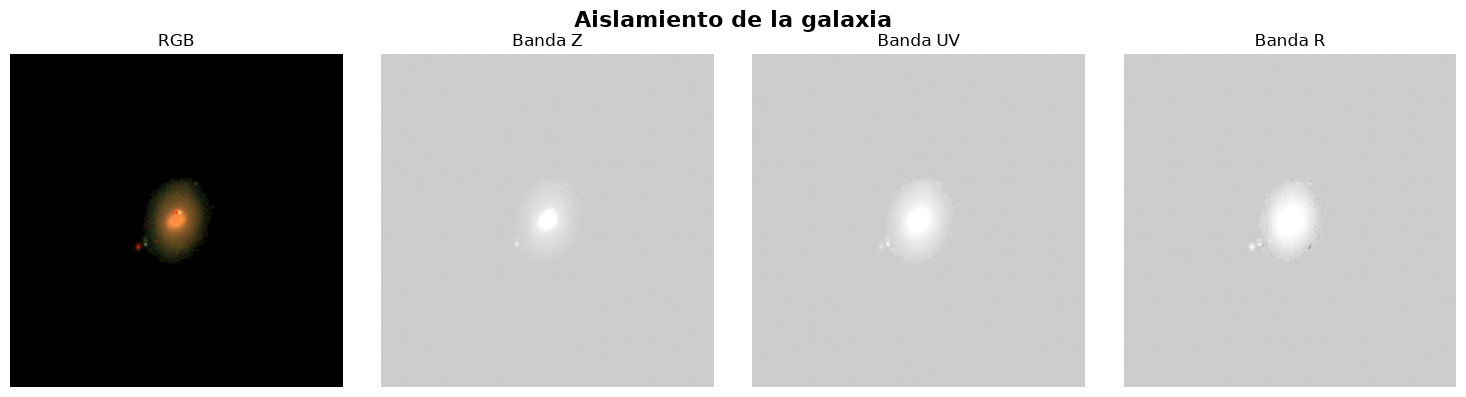

In [93]:
glx = limpieza_estrellas(image_data, bkgs['bkgs'], mascara[0])
glx_rgb = make_lupton_rgb(image_r=glx[2], image_g=glx[1], image_b=glx[0], stretch=0.1)

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
fig.suptitle('Aislamiento de la galaxia', fontsize=16, fontweight='bold')
axs[0].imshow(glx_rgb, origin='lower', norm = norm_imgs['Asym Per Lupton'])
axs[0].set_title('RGB')
axs[0].axis('off')
axs[1].imshow(glx[0], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
axs[1].set_title('Banda Z')
axs[1].axis('off')
axs[2].imshow(glx[1], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
axs[2].set_title('Banda UV')
axs[2].axis('off')
axs[3].imshow(glx[2], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
axs[3].set_title('Banda R')
axs[3].axis('off')

plt.tight_layout()
plt.show()

# Image segmentation - Spline

In [ ]:
def max_luz_spline (glx_limpia, mask):
    '''
    Descripción del pipeline:
    1. Cálculo de normalizaciones de todos los canales para obtener un sólo dato
    2. Se aplica inverse_gaussian_gradient para poder delimitar los bordes de la galaxia sumando todos los canales
    3. Otener el arreglo del spline con morphological_geodesic_active_contour
    4. Se obtiene la máscara binanria
    RETURN spline y máscara binaria, y normalización

    NOTA: SÓLO AL PASO 1 SE APLICA A LOS 3 CANALES, EL RESTO DE LOS PASOS SÓLO SE APLICA A UN SOLO CANAL, POR DEFAULT SERÁ UV
    '''


    # 1. cálculo de valores alpha para hacer el AsinhStrech
    _, med_cielo, std_cielo = sigma_clipped_stats(glx_limpia, sigma=3, maxiters=10)
    denominador = np.max(glx_limpia)-np.min(glx_limpia)
    alpha_est = (med_cielo-np.min(glx_limpia))/denominador


    minmax = MinMaxInterval()
    asin_est = AsinhStretch(a=alpha_est)

    minmax_norm = ImageNormalize(data=glx_limpia,interval=minmax, stretch=asin_est)

    #PASO 2
    arr_invgaus = inverse_gaussian_gradient(image=minmax_norm(glx_limpia[0]+glx_limpia[1]+glx_limpia[2]))
    #PASO 3
    snk_MGAC = morphological_geodesic_active_contour(
        gimage=arr_invgaus,
        num_iter=10,
        init_level_set=mask,
        threshold=0.1,
        balloon=0.2,
        smoothing=2,
    )
    #PASO 4
    mask_snk=ndimage.binary_fill_holes(snk_MGAC)
    mask_nn = mask_snk.astype(np.float32) # máscara para la neural network
    mask_cont = mask_snk.astype(np.int8) # spline para graficar

    return {
        'norms': minmax_norm,
        'inverse_gausse': arr_invgaus,
        'snk_mgac': snk_MGAC,
        'mask_nn':mask_nn,
        'mask_cont':mask_cont
    }

In [99]:
glx_final = max_luz_spline(glx, mascara[0])

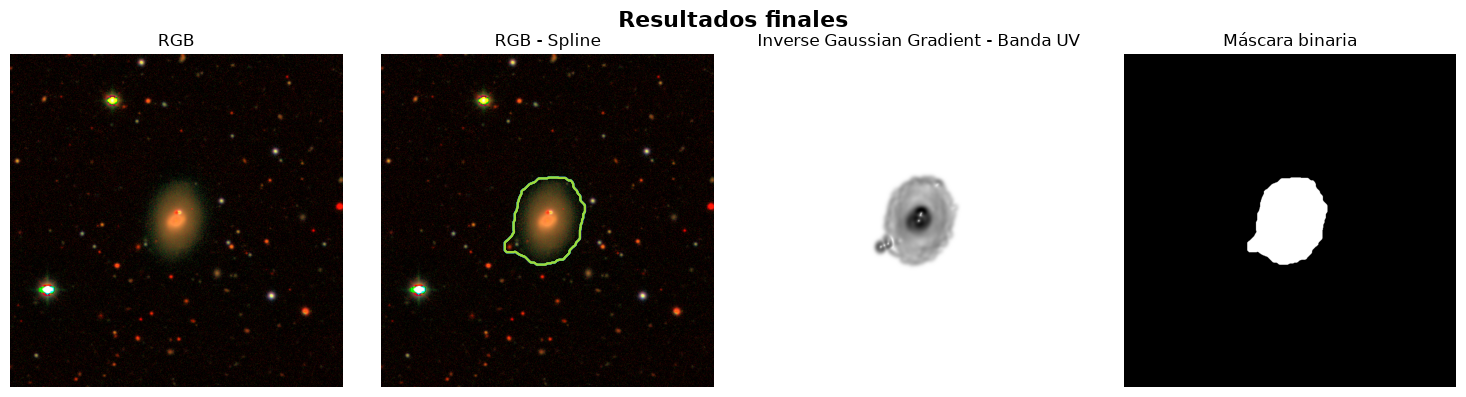

In [100]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
fig.suptitle('Resultados finales', fontsize=16, fontweight='bold')
axs[0].imshow(gal_rgb, origin='lower', norm = glx_final['norms'])
axs[0].set_title('RGB')
axs[0].axis('off')
axs[1].imshow(gal_rgb, origin='lower', norm = glx_final['norms'])
axs[1].contour(glx_final['mask_cont'])
axs[1].set_title('RGB - Spline')
axs[1].axis('off')
axs[2].imshow(glx_final['inverse_gausse'], cmap='grey', origin='lower' )
axs[2].set_title('Inverse Gaussian Gradient - Banda UV')
axs[2].axis('off')
axs[3].imshow(glx_final['mask_cont'], origin='lower', cmap='grey')
axs[3].set_title('Máscara binaria')
axs[3].axis('off')
plt.tight_layout()
plt.show()


# Prueba de generalización FITS

In [7]:
fits_files=os.listdir(Path.cwd()/Path('FITS'))
fits_path = Path.cwd()/Path('FITS')
for f in fits_files:
    pf = fits_path/Path(f)
    if f.split(sep="_")[1]=='grz.fits':
        # extracción del ID de la galaxia
        gname=f.split(sep="_")[0]
        #creación de folder
        pdir = Path(f'{fits_path}\{gname}')
        if not os.path.exists(pdir): os.mkdir(pdir)

        # extracción de datos del archivo fits
        hdulist= fits.open(pf)
        headers = fits.getheader(pf)
        image_data= fits.getdata(pf)
        hdulist.close()
        # graficas RAW
        gal_rgb = make_lupton_rgb(image_r=image_data[2], image_g=image_data[1], image_b=image_data[0], stretch=0.1)
        gal_chnls = image_data[2] + image_data[1] + image_data[0]
        luz_rgb = np.median(gal_rgb) + np.std(gal_rgb)*2
        luz_g = np.median(image_data[1]) + np.std(image_data[1])*2
        luz_r = np.median(image_data[2]) + np.std(image_data[2])*2
        luz_b = np.median(image_data[0]) + np.std(image_data[0])*2
        luz_ch = np.median(gal_chnls) + np.std(gal_chnls)*2
        fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,4))
        fig.suptitle(f'Imágenes RAW - {gname}', fontsize=16, fontweight='bold')
        ax[0].imshow(gal_rgb, vmin=luz_rgb,  origin='lower')
        ax[0].set_title(f'RGB')
        ax[0].axis('off')
        ax[1].imshow(image_data[0], vmax=luz_b, vmin=np.min(image_data[0]), origin='lower', cmap='grey')
        ax[1].set_title(f'Banda Z (B)')
        ax[1].axis('off')
        ax[2].imshow(image_data[1], vmax=luz_g, vmin=np.min(image_data[1]),  origin='lower', cmap='grey')
        ax[2].set_title(f'Banda UV (G)')
        ax[2].axis('off')
        ax[3].imshow(image_data[2], vmax=luz_r, vmin=np.min(image_data[2]), origin='lower', cmap='grey')
        ax[3].set_title(f'Banda R (R)')
        ax[3].axis('off')
        ax[4].imshow(gal_chnls, vmin=np.min(gal_chnls), vmax=luz_ch ,origin='lower', cmap='Greys')
        ax[4].set_title('Todos los canales')
        ax[4].axis('off')
        plt.tight_layout()
        plt.savefig(fname=f'{pdir}/RAW_IMG_{gname}.jpg',dpi=300, bbox_inches='tight')
        plt.close(fig)


        #Aislamiento de la galaxia
        bkgs = metricas_fondo(gal_chnls)
        norm_imgs = norm_fits(bkgs['fits'])
        #gráficas banda Z normalizadas
        fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
        axs = axs.ravel()
        fig.suptitle('Comparativo de Normalizaciones Banda Z', fontsize=16, fontweight='bold')
        for (k,v), ax in zip(norm_imgs.items(),axs):
            ax.imshow(bkgs['fits'], norm = v, origin='lower', cmap='grey')
            ax.set_title(f'{k}')
        plt.tight_layout()
        plt.savefig(fname=f'{pdir}/Norm_img_{gname}.jpg',dpi=300, bbox_inches='tight')
        plt.close(fig)

        #máscara Gaussiana
        mascara = mascara_gaussiana(gal_chnls, stats = 'std')
        #grafico la segmentación de la galaxia
        fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(15,10))
        fig.suptitle('Generaci{on máscara gaussiana}', fontsize=16, fontweight='bold')
        axs[0].imshow(gal_chnls, origin='lower', cmap="grey", norm = norm_imgs['Asym Per Lupton'])
        axs[0].set_title('Asym Per Lupton')
        mascara[1].imshow(ax=axs[1])
        axs[1].set_title('Gauss Kernel')
        axs[2].imshow(mascara[0], cmap='grey', origin='lower')
        axs[2].set_title('Máscara booleana')
        plt.tight_layout()
        plt.savefig(fname=f'{pdir}/mascara_Gauss_{gname}.jpg',dpi=300, bbox_inches='tight')
        plt.close(fig)

        #limpieza de estrellas
        glx = limpieza_estrellas(image_data, bkgs['bkgs'], mascara[0])
        glx_rgb = make_lupton_rgb(image_r=glx[2], image_g=glx[1], image_b=glx[0], stretch=0.1)
        fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
        fig.suptitle('Aislamiento de la galaxia', fontsize=16, fontweight='bold')
        axs[0].imshow(glx_rgb, origin='lower', norm = norm_imgs['Asym Per Lupton'])
        axs[0].set_title('RGB')
        axs[0].axis('off')
        axs[1].imshow(glx[0], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
        axs[1].set_title('Banda Z')
        axs[1].axis('off')
        axs[2].imshow(glx[1], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
        axs[2].set_title('Banda UV')
        axs[2].axis('off')
        axs[3].imshow(glx[2], origin='lower', norm = norm_imgs['Asym Per Lupton'], cmap='grey')
        axs[3].set_title('Banda R')
        axs[3].axis('off')
        plt.tight_layout()
        plt.savefig(fname=f'{pdir}/limpieza_estrellas_{gname}.jpg',dpi=300, bbox_inches='tight')
        plt.close(fig)

        #IMAGE SEGMENTATION
        glx_final = max_luz_spline(glx, mascara[0])
        fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
        fig.suptitle('Resultados finales', fontsize=16, fontweight='bold')
        axs[0].imshow(gal_rgb, origin='lower', norm = glx_final['norms'])
        axs[0].set_title('RGB')
        axs[0].axis('off')
        axs[1].imshow(gal_rgb, origin='lower', norm = glx_final['norms'])
        axs[1].contour(glx_final['mask_cont'])
        axs[1].set_title('RGB - Spline')
        axs[1].axis('off')
        axs[2].imshow(glx_final['inverse_gausse'], cmap='grey', origin='lower' )
        axs[2].set_title('Inverse Gaussian Gradient - Banda UV')
        axs[2].axis('off')
        axs[3].imshow(glx_final['mask_cont'], origin='lower', cmap='grey')
        axs[3].set_title('Máscara binaria')
        axs[3].axis('off')
        plt.tight_layout()
        plt.savefig(fname=f'{pdir}/img_seg_{gname}.jpg',dpi=300, bbox_inches='tight')
        plt.close(fig)
